# Direct Repeats — SNP frequency (model-detected subset)

Fork of `dr_snp_frequency_notebook.ipynb`. Only §4.1 differs: the DR set is
`Direct_Repeat_detected.bed` (model-detected, ~1.5k loci) instead of
all DR in `Direct_Repeat_test.csv`. Spacer is still recovered from the test CSV
by joining on (chr, motif_start, motif_end, strand).


# Library

Load this before running the rest of the notebook

In [1]:

try:
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    print('rpy2 loaded')
except Exception as e:
    print('rpy2 not available (R cells will fail, which is expected for the pipeline-only run):', e)


rpy2 not available (R cells will fail, which is expected for the pipeline-only run): No module named 'rpy2'


In [3]:


import re

def trinucl_subrate(snps, motifsequences):
    
    # One count and one array per possible trinucleotide.
    nucleotides = ['A','T','G','C','N']
    trinucleotides = []
    for x in nucleotides:
        for y in nucleotides:
            for z in nucleotides:
                trinucleotides.append(x+y+z)
    trinucleotidesdict = {}
    for trinucleotide in trinucleotides:
        trinucleotidesdict[trinucleotide] = [0,[]]

    # Count trinucleotide occurrences and match them against SNPs.
    for motifsequence in motifsequences:
        motifsequence = motifsequence.strip()
        if motifsequence[0] == '>':
            chrom, start, end = re.split('[:,\-]',motifsequence[1:])
            start = int(start)
            end = int(end)
        else:
            motifsequence = motifsequence.replace('a', 'A')
            motifsequence = motifsequence.replace('t', 'T')
            motifsequence = motifsequence.replace('c', 'C')
            motifsequence = motifsequence.replace('g', 'G')
            motifsequence = motifsequence.replace('n', 'N')
            for i in range(1, len(motifsequence)-1):
                trinucl = motifsequence[i-1]+motifsequence[i]+motifsequence[i+1]
                pos = start + i
                key = chrom+'|'+str(pos)+'|'+str(pos+1)
                trinucleotidesdict[trinucl][0] += 1
                if key in snpdict:
                    trinucleotidesdict[trinucl][1].append(snpdict[key])

    # Count each substitution type per trinucleotide and derive the rates.
    subrates = {}
    for trinucleotide in trinucleotidesdict:
        count, snps = trinucleotidesdict[trinucleotide]
        subs = [0,0,0,0,0] # A, T, G, C, N
        for snp in snps:
            ref, alt = snp
            if ref != trinucleotide[1]:
                print('ERROR: snp ref does not match center nucleotide')

# changed for multiple SNPs in same trinucl. The trinucl is counted once but SNPs are all counted. 
# This could (unlikely but mathematically possible, sum up to more than 1.0)

            if 'A' in alt:
                subs[0] +=1
            if 'T' in alt:
                subs[1] +=1
            if 'G' in alt:
                subs[2] +=1
            if 'C' in alt:
                subs[3] +=1
            if 'N' in alt:
                subs[4] += 1

        counter = 0
        nucls = ['A','T','G','C','N']
        for sub in subs:
            if count != 0:
                rate = float(int(sub) / count)
            else:
                rate = 0
            subrates[trinucleotide+'->'+nucls[counter]] = [rate,sub,count]
            counter += 1
    return(subrates)

# 4. Direct Repeats

End-to-end runnable pipeline (hg38 / gnomAD / detected-test DR). 



## Setup

All intermediate files are written into `results/dr_notebook_run/`

In [4]:
import os, sys, re, subprocess, random
from pathlib import Path
import pandas as pd
import numpy as np

BASE    = os.environ.get("SNP_AF_BASE", "/path/to/snp_af_analysis")
WORKDIR = f"{BASE}/results/dr_notebook_detected_run"
Path(WORKDIR).mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

os.environ["BASE"]        = BASE
os.environ["CHROM_SIZES"] = f"{BASE}/reference/hg38.chrom.sizes"
os.environ["GAPS_BED"]    = f"{BASE}/annotations/hg38_gaps.bed"
os.environ["CODING_BED"]  = f"{BASE}/annotations/coding_regions.bed" # GENCODE basic gene annotation, filtered to only include CDS regions
os.environ["REPEAT_BED"]  = f"{BASE}/annotations/repetitive_elements.bed" # RepeatMasker annotation from UCSC
os.environ["SNP_DIR"]     = f"{BASE}/snp_data/gnomad"
os.environ["PATH"]        = os.environ.get("BEDTOOLS_BIN", "") + ":" + os.environ["PATH"]
# Stage-1 (NR-Contrastive) outputs and experimental splits
# Override with environment variables; the defaults are the paths used for the paper.
PU_RESULTS      = os.environ.get("NONB_PU_RESULTS",
    "/path/to/pu_results")
EXPERIMENT_DATA = os.environ.get("NONB_EXPERIMENT_DATA",
    "/path/to/Experiment_Data")
IWTOMICS_DIR    = os.environ.get("IWTOMICS_DIR",
    "/path/to/nonb-nrcl-paper/snp_analysis/iwtomics")


random.seed(42)
np.random.seed(42)
print("cwd:", os.getcwd())
print("bedtools:", subprocess.run("which bedtools", shell=True, capture_output=True, text=True).stdout.strip())


cwd: /data/haotian/qianying/snp_af_analysis/results/dr_notebook_detected_run
bedtools: /home/haz19024/softwares/bedtools2/bin/bedtools


## 4.1 Retrieve annotation (model-detected DR)

`Direct_Repeat_detected.bed` contains ~1.5k model-selected DR loci (9 columns,
no spacer). Spacer is recovered from the test CSV by joining on
(chr, motif_start, motif_end, strand). 

In [5]:
DR_BED   = f"{PU_RESULTS}/Direct_Repeat/Direct_Repeat_detected.bed"
TEST_CSV = f"{EXPERIMENT_DATA}/Direct_Repeat_test.csv"

# Detected BED: chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value
dr_df = pd.read_csv(DR_BED, sep="\t")
print(f"detected DR rows: {len(dr_df)}")
dr_df["motif_start"] = dr_df["motif_start"].astype(int)
dr_df["motif_end"]   = dr_df["motif_end"].astype(int)
dr_df = dr_df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)
print(f"after dedup: {len(dr_df)}")

# Pull spacer from test CSV (features field)
test_df = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","features","label"])
test_df = test_df[test_df["label"] == "Direct_Repeat"].copy()
test_df["motif_start"] = test_df["motif_start"].astype(int)
test_df["motif_end"]   = test_df["motif_end"].astype(int)
_re_spacer = re.compile(r"spacer=(\d+)")
test_df["spacer"] = test_df["features"].apply(
    lambda s: int(_re_spacer.search(str(s)).group(1)) if _re_spacer.search(str(s)) else None)
test_df = test_df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"])

dr_df = dr_df.merge(test_df[["chr","motif_start","motif_end","strand","spacer"]],
                    on=["chr","motif_start","motif_end","strand"], how="left")
n_before = len(dr_df)
dr_df = dr_df.dropna(subset=["spacer"])
dr_df["spacer"] = dr_df["spacer"].astype(int)
print(f"with spacer filled: {len(dr_df)}/{n_before}")

# 1-based inclusive → 0-based half-open
dr_df["motif_start"] = dr_df["motif_start"] - 1
# motif_end already 1-based inclusive; -1 to get the last base (0-based), +1 for half-open → no change

dr_df[["chr","motif_start","motif_end","spacer"]].to_csv(
    "DirectRepeats.bed", sep="\t", header=False, index=False)
print(f"wrote DirectRepeats.bed with {len(dr_df)} rows")


detected DR rows: 1512
after dedup: 1512
with spacer filled: 1512/1512
wrote DirectRepeats.bed with 1512 rows


NCNR filter (remove overlaps with coding + repetitive) and apply the published 100-bp motif length threshold.


In [6]:
%%bash
set -euo pipefail

# Build hg38 NCNR = coding ∪ repetitive (merged) once
if [ ! -f NCNR.hg38.bed ]; then
    cat "$CODING_BED" "$REPEAT_BED" | sort -k1,1 -k2,2n | bedtools merge -i stdin > NCNR.hg38.bed
fi

bedtools intersect -a DirectRepeats.bed -b NCNR.hg38.bed -v > NCNR.DirectRepeats.bed
awk '{if ($3-$2<=100) print $0}' NCNR.DirectRepeats.bed > NCNR.DirectRepeats.100threshold.bed
bedtools sort -i NCNR.DirectRepeats.100threshold.bed > NCNR.DirectRepeats.100threshold.sorted.bed

wc -l DirectRepeats.bed NCNR.DirectRepeats.bed NCNR.DirectRepeats.100threshold.sorted.bed


 1512 DirectRepeats.bed
  634 NCNR.DirectRepeats.bed
  562 NCNR.DirectRepeats.100threshold.sorted.bed
 2708 total


## 4.2 Create Flanks

Add 2 kb flanks on each side.


In [7]:
%%bash
set -euo pipefail
paste NCNR.DirectRepeats.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.DirectRepeats.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNR.DirectRepeats.flanked.bed

wc -l NCNR.DirectRepeats.flanked.bed
head -2 NCNR.DirectRepeats.flanked.bed


562 NCNR.DirectRepeats.flanked.bed
chr1	1089706	1093792	86	+	1091706	1091792	0
chr1	3528416	3532449	33	+	3530416	3530449	3


## 4.3 Create Controls

Shuffle exclusion unions THREE sources so controls never fall in forbidden regions: (1) all DR motifs, (2) NCNR, (3) `hg38_gaps.bed`. 

In [8]:
%%bash
set -euo pipefail

cut -f 1-3 NCNR.DirectRepeats.100threshold.sorted.bed > _temp_DR

cat _temp_DR "$GAPS_BED" NCNR.hg38.bed \
  | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_DR.bed

bedtools shuffle -i NCNR.DirectRepeats.100threshold.sorted.bed \
    -excl exclude_DR.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 42 > _temp_DR_shuffled
bedtools sort -i _temp_DR_shuffled > NCNR.DR.shuffled.bed

paste NCNR.DR.shuffled.bed \
    <(bedtools slop -i NCNR.DR.shuffled.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2+1, "+", $2, $3, $4}' \
  > NCNR.DirectRepeats.shuffled.flanked.bed

rm -f _temp_DR _temp_DR_shuffled
wc -l NCNR.DirectRepeats.shuffled.flanked.bed
head -2 NCNR.DirectRepeats.shuffled.flanked.bed


562 NCNR.DirectRepeats.shuffled.flanked.bed
chr1	4386045	4390065	21	+	4388045	4388065	0
chr1	12768874	12772936	63	+	12770874	12770936	8


## 4.4 Pick non-overlapping windows

Python reimplementation of the published `Locuschoice.py`: greedy pass that, within each overlap cluster on a chromosome, keeps one random motif and drops the rest. This removes pseudo-replication from the 4 kb flanked windows.


In [9]:
def locuschoice(in_bed, out_bed, seed=42):
    rng = random.Random(seed)
    last_chrom = "chr0"
    last_end = 0
    tochoose = []
    nkept = 0
    with open(in_bed) as f_in, open(out_bed, "w") as f_out:
        for line in f_in:
            arr = line.rstrip("\n").split("\t")
            chrom = arr[0]; ws = int(arr[1]); we = int(arr[2])
            if chrom == last_chrom:
                if ws < last_end:
                    tochoose.append(arr); last_end = we
                else:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                    tochoose = [arr]; last_end = we
            else:
                if tochoose:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                tochoose = [arr]; last_chrom = chrom; last_end = we
        if tochoose:
            chosen = tochoose[rng.randint(0, len(tochoose)-1)]
            f_out.write("\t".join(chosen) + "\n"); nkept += 1
    print(f"{in_bed} -> {out_bed}: kept {nkept}")
    return nkept

locuschoice("NCNR.DirectRepeats.flanked.bed",          "NCNR.DirectRepeats.nooverlap.bed",          seed=42)
locuschoice("NCNR.DirectRepeats.shuffled.flanked.bed", "NCNR.DirectRepeats.shuffled.nooverlap.bed", seed=43)


NCNR.DirectRepeats.flanked.bed -> NCNR.DirectRepeats.nooverlap.bed: kept 560
NCNR.DirectRepeats.shuffled.flanked.bed -> NCNR.DirectRepeats.shuffled.nooverlap.bed: kept 562


562

## 4.5 Split Repeats, Spacer, and Flanks

Refactor of the published `Split.py` into a function. Derives repeat length as `(motif_len − spacer) / 2` (drops DRs where this isn't an integer or where the reconstructed end doesn't match).


In [10]:
def split_repeats(in_bed, out_bed):
    """Split each DR motif into LeftFlank | LeftRepeat | Spacer | RightRepeat | RightFlank.
    Output has 5 columns: chrom, start, end, locus_id, part_type.
    locus_id is a 0-indexed integer, assigned sequentially to accepted loci.
    """
    loci = 0; zero_spacers = 0; skipped = 0
    with open(in_bed) as fin, open(out_bed, "w") as fout:
        for line in fin:
            parts = line.rstrip("\n").split("\t")
            chrom, f_start, f_end, length, strand, l_start, l_end, spacer = parts[:8]
            spacer_i = int(spacer)
            motif_len = int(l_end) - int(l_start)
            R_len_f = (motif_len - spacer_i) / 2.0
            R_length = int(R_len_f)
            if float(R_length) != R_len_f:
                skipped += 1; continue
            R1_s = int(l_start);     R1_e = R1_s + R_length
            Sp_s = R1_e;             Sp_e = Sp_s + spacer_i
            R2_s = Sp_e;             R2_e = R2_s + R_length
            if R2_e != int(l_end):
                skipped += 1; continue
            lid = loci
            loci += 1
            if spacer_i == 0: zero_spacers += 1
            fout.write(f"{chrom}\t{f_start}\t{l_start}\t{lid}\tLeftFlank\n")
            fout.write(f"{chrom}\t{R1_s}\t{R1_e}\t{lid}\tLeftRepeat\n")
            fout.write(f"{chrom}\t{Sp_s}\t{Sp_e}\t{lid}\tSpacer\n")
            fout.write(f"{chrom}\t{R2_s}\t{R2_e}\t{lid}\tRightRepeat\n")
            fout.write(f"{chrom}\t{l_end}\t{f_end}\t{lid}\tRightFlank\n")
    print(f"{in_bed} -> {out_bed}: {loci} Loci, {zero_spacers} ZeroSpacers, skipped={skipped}")
    return loci, zero_spacers

n_motif, zs_motif = split_repeats("NCNR.DirectRepeats.nooverlap.bed",
                                  "NCNR.DirectRepeats.split.bed")
n_ctrl,  zs_ctrl  = split_repeats("NCNR.DirectRepeats.shuffled.nooverlap.bed",
                                  "NCNR.DirectRepeats.shuffled.split.bed")

N_MOTIF        = n_motif
N_MOTIF_SPACER = n_motif - zs_motif
N_CTRL         = n_ctrl
N_CTRL_SPACER  = n_ctrl - zs_ctrl
print(f"\nN_MOTIF={N_MOTIF}  N_MOTIF_SPACER={N_MOTIF_SPACER}  "
      f"N_CTRL={N_CTRL}  N_CTRL_SPACER={N_CTRL_SPACER}")
with open("split_counts.txt", "w") as f:
    f.write(f"N_MOTIF\t{N_MOTIF}\nN_MOTIF_SPACER\t{N_MOTIF_SPACER}\n"
            f"N_CTRL\t{N_CTRL}\nN_CTRL_SPACER\t{N_CTRL_SPACER}\n")


NCNR.DirectRepeats.nooverlap.bed -> NCNR.DirectRepeats.split.bed: 464 Loci, 151 ZeroSpacers, skipped=96
NCNR.DirectRepeats.shuffled.nooverlap.bed -> NCNR.DirectRepeats.shuffled.split.bed: 466 Loci, 152 ZeroSpacers, skipped=96

N_MOTIF=464  N_MOTIF_SPACER=313  N_CTRL=466  N_CTRL_SPACER=314


## 4.6 Intersect annotations with variation datasets

Per-chromosome intersect with gnomAD (`snp_data/gnomad/chr{N}_snps.bed`). A single `bedtools intersect` against the 30 GB `all_chroms_snps.bed` would be impractical; looping per chromosome produces the same output at a fraction of the memory / time.


In [11]:
def intersect_per_chrom(bed_path, out_path):
    snp_dir = os.environ["SNP_DIR"]
    chroms = sorted(pd.read_csv(bed_path, sep="\t", header=None)[0].unique())
    total = 0
    with open(out_path, "w") as fout:
        for c in chroms:
            snp_file = f"{snp_dir}/{c}_snps.bed"
            if not os.path.exists(snp_file):
                print(f"  skip {c} (no {snp_file})"); continue
            cmd = (f'awk \'$1=="{c}"\' {bed_path} '
                   f'| bedtools intersect -wa -wb -a stdin -b {snp_file} -loj')
            res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            if res.stdout:
                fout.write(res.stdout)
                total += res.stdout.count("\n")
    print(f"{bed_path} -> {out_path}: {total} lines")
    return total

# bedtools intersect needs a sorted BED
for p in ("NCNR.DirectRepeats.split.bed", "NCNR.DirectRepeats.shuffled.split.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("NCNR.DirectRepeats.split.bed",
                    "NCNR.DirectRepeats.gnomAD.intersect")
intersect_per_chrom("NCNR.DirectRepeats.shuffled.split.bed",
                    "NCNR.DirectRepeats.gnomAD.shuffled.intersect")


NCNR.DirectRepeats.split.bed -> NCNR.DirectRepeats.gnomAD.intersect: 511879 lines
NCNR.DirectRepeats.shuffled.split.bed -> NCNR.DirectRepeats.gnomAD.shuffled.intersect: 497840 lines


497840

Compute relative positions / fractional bins per SNP (refactor of `RelativePositions_DirectRepeats.py`; R_repeat=50 bins, spacer=80 bins).


In [1]:
REPEAT_BINS = 50
SPACER_BINS = 80
scaledpositions_Repeat = [round(i,4) for i in np.arange(1, REPEAT_BINS*2, 2.0)/(REPEAT_BINS*2)]
scaledpositions_Spacer = [round(i,4) for i in np.arange(1, SPACER_BINS*2, 2.0)/(SPACER_BINS*2)]

def relative_positions(intersect_path, out_csv):
    """Refactor of RelativePositions_DirectRepeats.py.
    Input: per-sub-annotation intersect with gnomAD (split.bed has 5 cols: chrom,start,end,locus_id,part_type).
    Output: CSV with scaled per-SNP position for each bin-assigned match. Optional — used only if
    you later want to feed an R plotting pipeline.
    """
    colnames = ["chrom","start","end","locus_id","length",
                "snp_start","snp_end","snp_pos","snp_coord_inwindow","ref","alt"]
    rows = []
    with open(intersect_path) as f:
        for line in f:
            arr = line.rstrip("\n").split("\t")
            if len(arr) < 8:
                continue
            chrom, start, end = arr[0], int(arr[1]), int(arr[2])
            locus_id, snp_pos = arr[3], arr[4]
            length = end - start
            # -loj no-overlap: "." "-1" "-1"
            if len(arr) >= 6 and arr[5] == ".":
                rows.append([chrom,start,end,locus_id,length,"NA","NA",snp_pos,"NA","NA","NA"])
                continue
            snpstart, snpend = int(arr[6]), int(arr[7])
            ref, alt = "NA", "NA"
            if snp_pos == "LeftFlank":
                coord = -(end - snpstart)
                rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,coord,ref,alt])
            elif snp_pos == "RightFlank":
                coord = snpend - start
                rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,coord,ref,alt])
            elif snp_pos in ("LeftRepeat","RightRepeat"):
                if length == 0: continue
                fs = (snpstart - start) / length
                fe = (snpend   - start) / length
                for i in scaledpositions_Repeat:
                    if i >= fs and i < fe:
                        rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,i,ref,alt])
            elif snp_pos == "Spacer":
                if length == 0: continue
                fs = (snpstart - start) / length
                fe = (snpend   - start) / length
                for i in scaledpositions_Spacer:
                    if i >= fs and i < fe:
                        rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,i,ref,alt])

    pd.DataFrame(rows, columns=colnames).to_csv(out_csv)
    print(f"{intersect_path} -> {out_csv}: {len(rows)} rows")

relative_positions("NCNR.DirectRepeats.gnomAD.intersect",
                   "NCNR.DirectRepeats.gnomAD.intersect.csv")
relative_positions("NCNR.DirectRepeats.gnomAD.shuffled.intersect",
                   "NCNR.DirectRepeats.gnomAD.shuffled.intersect.csv")


## 4.7 Plot Results (official R IWTomics + ggplot)

Replaces the previous Python-coded permutation test with the official **IWTomics**
R package (Bioconductor). Three steps:

1. **Build per-locus matrices** in Python from the per-sub-annotation `.intersect`
   files produced in §4.6, compute per-bin SNP frequencies, save matrices +
   frequencies + counts to disk.
2. **Run IWTomics** in R via `Rscript` — builds `IWTomicsData` for left flank,
   right flank, and center (LeftRepeat | Spacer | RightRepeat), runs
   `IWTomicsTest` (two-sample mean test, B=1000 permutations, α=0.01), and saves
   `adj_pvalue_curve_left/right/center` to three `.RData` files.
3. **Plot in R** with ggplot2 (mirrors `Supplementary code 2.ipynb` §4.7) —
   loads the `.RData` and the SNP-frequency CSVs, makes the 5-panel
   `LeftFlank | LeftRepeat | Spacer | RightRepeat | RightFlank` figure, saves
   to PDF + PNG, and Python displays the PNG inline.

R is invoked from `$R_BIN` (IWTomics 1.26.0,
ggplot2/grid/gridExtra installed). No rpy2 dependency required.


In [13]:
# Build per-locus matrices and per-bin SNP frequencies, save for R
import numpy as np, pandas as pd, json, os
from pathlib import Path

# Allow running cell 25 from a fresh kernel (without re-running cells 7+19):
# restore the workdir + counts from split_counts.txt that cell 19 wrote.
if "WORKDIR" not in dir() or not os.path.isdir(WORKDIR):
    WORKDIR = "/path/to/snp_af_analysis/results/dr_notebook_detected_run"
    os.chdir(WORKDIR)
if any(v not in dir() for v in ("N_MOTIF", "N_CTRL", "N_MOTIF_SPACER", "N_CTRL_SPACER")):
    _counts = dict(line.strip().split("\t") for line in open("split_counts.txt"))
    N_MOTIF        = int(_counts["N_MOTIF"])
    N_CTRL         = int(_counts["N_CTRL"])
    N_MOTIF_SPACER = int(_counts["N_MOTIF_SPACER"])
    N_CTRL_SPACER  = int(_counts["N_CTRL_SPACER"])
    print(f"loaded counts from split_counts.txt: N_MOTIF={N_MOTIF}, N_CTRL={N_CTRL}, "
          f"N_MOTIF_SPACER={N_MOTIF_SPACER}, N_CTRL_SPACER={N_CTRL_SPACER}")

MAX_FLANK   = 100
REPEAT_BINS = 50
SPACER_BINS = 80
CENTER_BINS = 2 * REPEAT_BINS + SPACER_BINS

scaledposRepeats = [round(i, 4) for i in np.arange(1, REPEAT_BINS * 2, 2.0) / (REPEAT_BINS * 2)]
scaledposSpacer  = [round(i, 4) for i in np.arange(1, SPACER_BINS * 2, 2.0) / (SPACER_BINS * 2)]

part_offsets = {
    "LeftRepeat":  0,
    "Spacer":      REPEAT_BINS,
    "RightRepeat": REPEAT_BINS + SPACER_BINS,
}


def _build_matrices(intersect_path, n_loci):
    left_mat   = np.zeros((n_loci, MAX_FLANK),   dtype=np.float32)
    center_mat = np.zeros((n_loci, CENTER_BINS), dtype=np.float32)
    right_mat  = np.zeros((n_loci, MAX_FLANK),   dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8:
                continue
            lid   = int(f[3])
            ps    = int(f[1]); pe = int(f[2])
            ptype = f[4]
            if len(f) >= 6 and f[5] == ".":     # no-overlap row
                continue
            snp_start = int(f[6])
            plen = pe - ps
            key  = (lid, ptype, snp_start)
            if key in seen:
                continue
            seen.add(key)
            if ptype == "LeftFlank":
                coord = -(pe - snp_start)              # −1, −2 … −2000
                idx   = coord + MAX_FLANK              # keep last MAX_FLANK
                if 0 <= idx < MAX_FLANK:
                    left_mat[lid, idx] += 1
            elif ptype == "RightFlank":
                coord = snp_start - ps                 # 0 .. 1999
                if 0 <= coord < MAX_FLANK:
                    right_mat[lid, coord] += 1
            elif ptype in part_offsets:
                if plen == 0:
                    continue
                off    = part_offsets[ptype]
                is_rep = ptype.endswith("Repeat")
                sp_lst = scaledposRepeats if is_rep else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(sp_lst):
                    if sp >= fs and sp < fe:
                        center_mat[lid, off + i] += 1
    return left_mat, center_mat, right_mat


def _spacer_loci_mask(split_bed_path, n_loci):
    # True for each locus whose Spacer row has start != end (non-zero spacer)
    mask = np.zeros(n_loci, dtype=bool)
    with open(split_bed_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 5 or f[4] != "Spacer":
                continue
            if int(f[2]) > int(f[1]):
                mask[int(f[3])] = True
    return mask


print("Building per-locus matrices (motif) …")
dr_left, dr_center, dr_right = _build_matrices(
    "NCNR.DirectRepeats.gnomAD.intersect", N_MOTIF)
print("Building per-locus matrices (control) …")
ct_left, ct_center, ct_right = _build_matrices(
    "NCNR.DirectRepeats.gnomAD.shuffled.intersect", N_CTRL)

# Subpart matrices (split center back into LeftRepeat / Spacer / RightRepeat)
dr_LR = dr_center[:, 0                      : REPEAT_BINS                ]
dr_Sp = dr_center[:, REPEAT_BINS            : REPEAT_BINS + SPACER_BINS  ]
dr_RR = dr_center[:, REPEAT_BINS + SPACER_BINS : CENTER_BINS             ]
ct_LR = ct_center[:, 0                      : REPEAT_BINS                ]
ct_Sp = ct_center[:, REPEAT_BINS            : REPEAT_BINS + SPACER_BINS  ]
ct_RR = ct_center[:, REPEAT_BINS + SPACER_BINS : CENTER_BINS             ]

# For Spacer, restrict to loci with non-zero spacer (matches published divisor)
mask_dr_sp = _spacer_loci_mask("NCNR.DirectRepeats.split.bed",          N_MOTIF)
mask_ct_sp = _spacer_loci_mask("NCNR.DirectRepeats.shuffled.split.bed", N_CTRL)
dr_Sp_f    = dr_Sp[mask_dr_sp]
ct_Sp_f    = ct_Sp[mask_ct_sp]
print(f"spacer-loci kept: motif={len(dr_Sp_f)}/{N_MOTIF}  ctrl={len(ct_Sp_f)}/{N_CTRL}")

# Per-bin frequencies (used by the R ggplot cell)
left_freq        = dr_left.sum(0)  / N_MOTIF
right_freq       = dr_right.sum(0) / N_MOTIF
ctrl_left_freq   = ct_left.sum(0)  / N_CTRL
ctrl_right_freq  = ct_right.sum(0) / N_CTRL
left_rep_freq    = dr_LR.sum(0)    / N_MOTIF
right_rep_freq   = dr_RR.sum(0)    / N_MOTIF
ctrl_left_rep    = ct_LR.sum(0)    / N_CTRL
ctrl_right_rep   = ct_RR.sum(0)    / N_CTRL
spacer_freq      = dr_Sp.sum(0)    / max(N_MOTIF_SPACER, 1)
ctrl_spacer_freq = ct_Sp.sum(0)    / max(N_CTRL_SPACER,  1)

print(f"flank  range  (motif):  {left_freq.min():.4f} .. {right_freq.max():.4f}")
print(f"spacer range (motif):   {spacer_freq.min():.4f} .. {spacer_freq.max():.4f}")

# persist matrices + frequencies + counts for R
def _save_mat(arr, path):
    np.savetxt(path, arr, fmt="%.6g", delimiter="\t")

print("\nSaving matrices for R …")
_save_mat(dr_left,  "iwt_motif_left.tsv");   _save_mat(ct_left,  "iwt_ctrl_left.tsv")
_save_mat(dr_right, "iwt_motif_right.tsv");  _save_mat(ct_right, "iwt_ctrl_right.tsv")
_save_mat(dr_LR,    "iwt_motif_LR.tsv");     _save_mat(ct_LR,    "iwt_ctrl_LR.tsv")
_save_mat(dr_RR,    "iwt_motif_RR.tsv");     _save_mat(ct_RR,    "iwt_ctrl_RR.tsv")
_save_mat(dr_Sp_f,  "iwt_motif_Sp.tsv");     _save_mat(ct_Sp_f,  "iwt_ctrl_Sp.tsv")

pd.DataFrame({
    "LeftFlank":       left_freq,
    "ctrl_LeftFlank":  ctrl_left_freq,
}).to_csv("iwt_freq_LeftFlank.csv", index=False)
pd.DataFrame({
    "RightFlank":       right_freq,
    "ctrl_RightFlank":  ctrl_right_freq,
}).to_csv("iwt_freq_RightFlank.csv", index=False)
# pd.Series wrap forces NaN-padding when columns have different lengths
# (LeftRepeat/RightRepeat are length 50, Spacer is length 80).
pd.DataFrame({
    "LeftRepeat":       pd.Series(left_rep_freq),
    "ctrl_LeftRepeat":  pd.Series(ctrl_left_rep),
    "Spacer":           pd.Series(spacer_freq),
    "ctrl_Spacer":      pd.Series(ctrl_spacer_freq),
    "RightRepeat":      pd.Series(right_rep_freq),
    "ctrl_RightRepeat": pd.Series(ctrl_right_rep),
}).to_csv("iwt_freq_center.csv", index=False)

with open("iwt_counts.json", "w") as fh:
    json.dump({
        "N_MOTIF":        int(N_MOTIF),
        "N_CTRL":         int(N_CTRL),
        "N_MOTIF_SPACER": int(N_MOTIF_SPACER),
        "N_CTRL_SPACER":  int(N_CTRL_SPACER),
        "MAX_FLANK":      MAX_FLANK,
        "REPEAT_BINS":    REPEAT_BINS,
        "SPACER_BINS":    SPACER_BINS,
    }, fh)

print("done — wrote 10 matrix TSVs, 3 freq CSVs, iwt_counts.json")


loaded counts from split_counts.txt: N_MOTIF=464, N_CTRL=466, N_MOTIF_SPACER=313, N_CTRL_SPACER=314
Building per-locus matrices (motif) …
Building per-locus matrices (control) …
spacer-loci kept: motif=313/464  ctrl=314/466
flank  range  (motif):  0.1853 .. 0.2953
spacer range (motif):   0.3035 .. 0.3834

Saving matrices for R …
done — wrote 10 matrix TSVs, 3 freq CSVs, iwt_counts.json


## 4.7b Run IWTomics in an external R session

IWTomics runs outside the notebook, in a dedicated R environment.

### How to run

1. Make sure cell 25 above has finished — it writes the matrix TSVs and frequency
   CSVs that IWTomics needs.

2. Open a terminal and start R from the dedicated conda env:

   ```bash
   $R_BIN
   ```

3. In the R session, run the script:

   ```text
   /path/to/snp_af_analysis/iwtomics_dr/run_iwtomics_dr.R
   ```

   `source()` the whole file, or run it block by block. The left flank is
   worked through explicitly (read matrices → build IWTomicsData →
   IWTomicsTest → adjusted_pval → save); the same procedure is then applied
   as a function to the right flank, LeftRepeat, Spacer and RightRepeat, and
   the three center sub-parts are combined at the end.

4. When the script finishes, the workdir of this notebook will contain three
   new files:

   ```
   DirectRepeats_motif_vs_control_IWTomics_left_0.01.RData
   DirectRepeats_motif_vs_control_IWTomics_right_0.01.RData
   DirectRepeats_motif_vs_control_IWTomics_center_0.01.RData
   ```

5. Run the next cell below to produce the 5-panel ggplot figure (it just
   `load()`s the three .RData files and the frequency CSVs).


plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript …
saved dr_snp_frequency_notebook.{pdf,png}



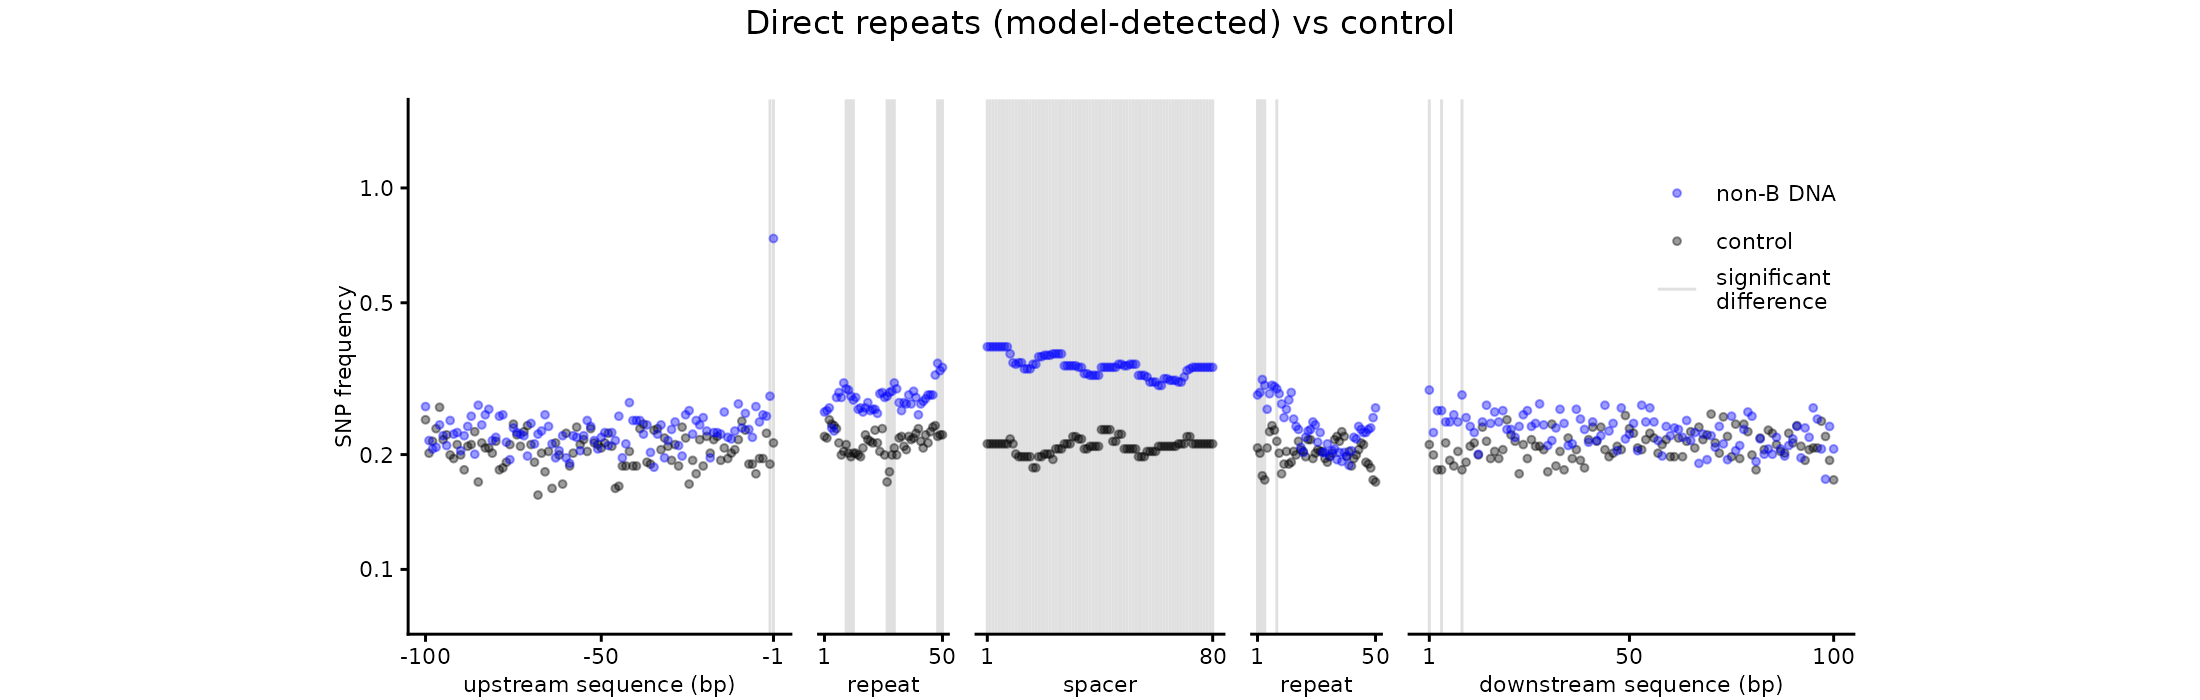

In [15]:
# R + ggplot 5-panel plot (mirrors Supplementary code 2 §4.7)
import subprocess
from pathlib import Path
from IPython.display import Image, display
import os
os.chdir("/path/to/snp_af_analysis/results/dr_notebook_detected_run")

R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r'''
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/dr_notebook_detected_run")

# load IWTomics significance
load("DirectRepeats_motif_vs_control_IWTomics_left_0.01.RData")
load("DirectRepeats_motif_vs_control_IWTomics_right_0.01.RData")
load("DirectRepeats_motif_vs_control_IWTomics_center_0.01.RData")

# load per-bin frequencies (computed in Python from the per-locus matrices)
freqL <- read.csv("iwt_freq_LeftFlank.csv")     # 100 rows
freqR <- read.csv("iwt_freq_RightFlank.csv")    # 100 rows
freqC <- read.csv("iwt_freq_center.csv")        # 80 rows (NA pad short cols)

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                            Freq   = freqL$LeftFlank,
                            C_Freq = freqL$ctrl_LeftFlank,
                            Signif = adj_pvalue_curve_left$significant)

RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                            Freq   = freqR$RightFlank,
                            C_Freq = freqR$ctrl_RightFlank,
                            Signif = adj_pvalue_curve_right$significant)

LR_sig <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == "LeftRepeat",  "significant"]
Sp_sig <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == "Spacer",      "significant"]
RR_sig <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == "RightRepeat", "significant"]

LeftRepeatDf  <- data.frame(Levels = seq(1, 50, 1),
                             Freq   = freqC$LeftRepeat[1:50],
                             C_Freq = freqC$ctrl_LeftRepeat[1:50],
                             Signif = LR_sig)
SpacerDf      <- data.frame(Levels = seq(1, 80, 1),
                             Freq   = freqC$Spacer[1:80],
                             C_Freq = freqC$ctrl_Spacer[1:80],
                             Signif = Sp_sig)
RightRepeatDf <- data.frame(Levels = seq(1, 50, 1),
                             Freq   = freqC$RightRepeat[1:50],
                             C_Freq = freqC$ctrl_RightRepeat[1:50],
                             Signif = RR_sig)

# y-range from data (auto, log-scale)
allv <- c(LeftFlankDf$Freq,   LeftFlankDf$C_Freq,
          RightFlankDf$Freq,  RightFlankDf$C_Freq,
          LeftRepeatDf$Freq,  LeftRepeatDf$C_Freq,
          SpacerDf$Freq,      SpacerDf$C_Freq,
          RightRepeatDf$Freq, RightRepeatDf$C_Freq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

# Hardcoded "nice" tick positions (same style as Supplementary code 2 cell 164,
# adjusted for our data range ~0.05-0.7)
Y_BREAKS <- c(0.1, 0.2, 0.5, 1)

cols <- c("non-B DNA"            = rgb(t(col2rgb("blue")),  alpha = 100, maxColorValue = 255),
          "significant\ndifference" = "grey88",
          "control"              = rgb(t(col2rgb("black")), alpha = 100, maxColorValue = 255))

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

base_panel <- function(df, xlab, n_bins) {
  ggplot(df, aes(x = Levels)) +
    geom_vline(xintercept = df$Levels[df$Signif], col = "gray88") +
    geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
    geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
    theme_classic() +
    theme(legend.position = "none",
          axis.text.x = element_text(size = 8, family = "sans"),
          axis.title.x = element_text(size = 8, family = "sans"),
          axis.title.y = element_blank(),
          axis.text.y  = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line.y  = element_blank()) +
    labs(x = xlab) +
    scale_colour_manual(name = "", values = cols) +
    scale_x_continuous(breaks = c(1, n_bins), limits = c(1, n_bins)) +
    theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
    scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)
}
p2 <- base_panel(LeftRepeatDf,  "repeat", 50)
p3 <- base_panel(SpacerDf,      "spacer", 80)
p4 <- base_panel(RightRepeatDf, "repeat", 50)

p5 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\ndifference")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 8, family = "sans"),
        legend.position = c(0.99, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("non-B DNA", "control", "significant\ndifference")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 3))

g <- arrangeGrob(p1, p2, p3, p4, p5, ncol = 5,
                 widths = unit(c(60, 20, 35, 20, 60),
                               c("mm", "mm", "mm", "mm", "mm")),
                 top = textGrob("Direct repeats (model-detected) vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("dr_snp_frequency_notebook.pdf", g, width = 11, height = 3.5, dpi = 300,bg='white')
ggsave("dr_snp_frequency_notebook.png", g, width = 11, height = 3.5, dpi = 200,bg='white')
cat("saved dr_snp_frequency_notebook.{pdf,png}\n")
'''

Path("plot_dr_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} …")
proc = subprocess.run([R_BIN, "--vanilla", "plot_dr_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("dr_snp_frequency_notebook.png"))


## 4.8 Permuting tests and controls

Generates the permuted-null CSVs (1000 permutations) that feed IWTomics.
Args for `Permuting.py` are:
`<motif_csv> <ctrl_csv> N_motif N_motif_spacer N_ctrl N_ctrl_spacer <out_motif> <out_ctrl>`

Fill in the four counts from the `Split.py` printout for this run:
`LociCount` and `LociCount − ZeroSpacers` for the motif and the control.


In [ ]:
#Permuting.py

import sys
import random
from collections import Counter
import pandas as pd

def extract_pos(infile): # this extract all snps in different \
                        #sections of a same non-B DNA loci
    infile.readline() #skip first line
    loci = {}
    last_pos = ''
    for line in infile:
        array = line.strip().split(',')
      
        if len(array) == 12: # G4s have one more columns, snp_pos is the section, snp_distance is the scaled position
            chrom, start, end, snp_pos, snpdistance = array[1], array[2], array[3], array[8], array[9]
        elif len(array) == 11:
            chrom, start, end, snp_pos, snpdistance = array[1], array[2], array[3], array[7], array[8]            
        else:
            print('Array length error')
        
        #next we group all SNPs that came from the same non-B locus
        if snp_pos == 'flank1' or snp_pos == 'LeftFlank':
            if last_pos == 'flank2' or last_pos == 'RightFlank':#should always be the start of a locus but the first one
                locus = chrom+"|"+start+"|"+end
                loci[locus] = locus_array
                
                locus_start = start
                locus_array = []
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)
                
            elif last_pos == '':#first start
                locus_start = start
                locus_array = []
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)  
                
            else:
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)
        else:
            if snpdistance!= 'NA':
                locus_array.append(snp_pos+'|'+snpdistance)
            locus_end = end
            
        last_pos = snp_pos
            
    locus = chrom+"|"+start+"|"+end #last iteration
    loci[locus] = locus_array #last iteration
    return(loci)

def count_freqs(loci, denominator, optional_denominator):
    
    subparts = {}
    for locus in loci:

        
        for snp in locus:        
            snp_pos, snp_coord = snp.split('|')
            if snp_pos in subparts:
                subparts[snp_pos].append(snp_coord)
            else:
                subparts[snp_pos] = [snp_coord]
            
    rows = []
    for subpart in subparts:
        freq = Counter(subparts[subpart])
        for value in freq.items():
            snp_coord, count = value
            if subpart == 'Spacer':
                freq = float(count) / optional_denominator
            else:
                freq = float(count) / denominator
            
            rows.append([subpart, float(snp_coord), freq])
        
    return(rows)
    

colnames = ['subpart','snp_coord','freq']

pool = []

infile = open(sys.argv[1], 'rt')
loci_dict = extract_pos(infile)
loci = []


for locus in loci_dict:
    pool.append(loci_dict[locus])
    loci.append(loci_dict[locus])
    
first_col = count_freqs(loci, int(sys.argv[3]), int(sys.argv[4]))
loci_df = pd.DataFrame(data=first_col, columns=colnames)


infile = open(sys.argv[2], 'rt')
ctrl_loci_dict = extract_pos(infile)
ctrl_loci = []

for locus in ctrl_loci_dict:
    pool.append(ctrl_loci_dict[locus])
    ctrl_loci.append(ctrl_loci_dict[locus])

first_ctrl_col = count_freqs(ctrl_loci, int(sys.argv[5]), int(sys.argv[6]))    
ctrl_loci_df = pd.DataFrame(data=first_ctrl_col, columns=colnames)



permutation = 1
while permutation <= 1000:
    colnames = ['subpart','snp_coord', 'freq '+str(permutation)]

    random.shuffle(pool)
    random_loci = pool[:int(sys.argv[3])]
    random_ctrl_loci = pool[int(sys.argv[3]):]
    
    
    new_col = count_freqs(random_loci, int(sys.argv[3]), int(sys.argv[4]))
    new_ctrl_col = count_freqs(random_ctrl_loci, int(sys.argv[5]), int(sys.argv[6]))
    new_df = pd.DataFrame(data=new_col, columns=colnames)
    new_ctrl_df = pd.DataFrame(data=new_ctrl_col, columns=colnames)

    loci_df = pd.merge(loci_df, new_df, how='outer', on=['subpart','snp_coord'])
    ctrl_loci_df = pd.merge(ctrl_loci_df, new_ctrl_df, how='outer', on=['subpart','snp_coord'])

    permutation += 1



pd.DataFrame.to_csv(loci_df, sys.argv[7])  
pd.DataFrame.to_csv(ctrl_loci_df, sys.argv[8])  


```
# Fill in the four counts from Split.py for this run, then run:
python Permuting.py \
    NCNR.DirectRepeats.gnomAD.intersect.csv \
    NCNR.DirectRepeats.gnomAD.shuffled.intersect.csv \
    <N_motif> <N_motif_nonzero_spacer> <N_ctrl> <N_ctrl_nonzero_spacer> \
    NCNR.DirectRepeats.gnomAD.permuted \
    NCNR.DirectRepeats.gnomAD.shuffled.permuted
```


## 4.9 Frequencies of subsitution types

In [ ]:
%%bash
# List SNPs at positions of interest and adjust coordinates for trinucleotide context
awk '{if ($5=="+") print $0 }' NCNR.DirectRepeats.nooverlap.bed | awk 'BEGIN {OFS="\t"} {print $1, $6-2, $6+1}' | awk '{if ($2>0) print $0}'> NCNR.DirectRepeats.trinucl.left.bed
awk '{if ($5=="+") print $0 }' NCNR.DirectRepeats.shuffled.nooverlap.bed | awk 'BEGIN {OFS="\t"} {print $1, $6-2, $6+1}' | awk '{if ($2>0) print $0}'> NCNR.DirectRepeats.shuffled.trinucl.left.bed

awk '{if ($5=="+") print $0 }' NCNR.DirectRepeats.nooverlap.bed |awk 'BEGIN {OFS="\t"} {print $1, $7-1, $7+2}' > NCNR.DirectRepeats.trinucl.right.bed
awk '{if ($5=="+") print $0 }' NCNR.DirectRepeats.shuffled.nooverlap.bed |awk 'BEGIN {OFS="\t"} {print $1, $7-1, $7+2}' > NCNR.DirectRepeats.shuffled.trinucl.right.bed


```
bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.DirectRepeats.trinucl.left.bed > NCNR.DirectRepeats.trinucl.left.fa
bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.DirectRepeats.shuffled.trinucl.left.bed > NCNR.DirectRepeats.shuffled.trinucl.left.fa

bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.DirectRepeats.trinucl.right.bed > NCNR.DirectRepeats.trinucl.right.fa
bedtools getfasta -fi ../LocalVariation/hg19.fa -bed NCNR.DirectRepeats.shuffled.trinucl.right.bed > NCNR.DirectRepeats.shuffled.trinucl.right.fa
```

In [ ]:
## Match SNPs of interest with SNP dictionary to obtain substitution type
import itertools

Test = open('NCNR.DirectRepeats.trinucl.left.fa', 'rt')
Control = open('NCNR.DirectRepeats.shuffled.trinucl.left.fa', 'rt')

permutations = itertools.permutations(['A','T','G','C'], 2)
rows = []
for permutation in permutations:
    rows.append(trinucl_test(snpdict, Test, Control, permutation[0], permutation[1]))
    Test.seek(0)
    Control.seek(0)
    
colnames = ['ref','alt','test freq','ctrl freq', 'odds ratio', 'pvalue']
trinucl_df = pd.DataFrame(data=rows, columns=colnames)

trinucl_df = trinucl_df[trinucl_df['test freq'] != 'NA']

p_adjusted = multipletests(trinucl_df.pvalue, alpha=0.05, method='bonferroni')

trinucl_df['Adj. p-val'] = p_adjusted[1] 
del trinucl_df['pvalue']
print(trinucl_df)


In [ ]:
## Match SNPs of interest with SNP dictionary to obtain substitution type
import itertools

Test = open('NCNR.DirectRepeats.trinucl.right.fa', 'rt')
Control = open('NCNR.DirectRepeats.shuffled.trinucl.right.fa', 'rt')

permutations = itertools.permutations(['A','T','G','C'], 2)
rows = []
for permutation in permutations:
    rows.append(trinucl_test(snpdict, Test, Control, permutation[0], permutation[1]))
    Test.seek(0)
    Control.seek(0)
    
colnames = ['ref','alt','test freq','ctrl freq', 'odds ratio', 'pvalue']
trinucl_df = pd.DataFrame(data=rows, columns=colnames)

trinucl_df = trinucl_df[trinucl_df['test freq'] != 'NA']

p_adjusted = multipletests(trinucl_df.pvalue, alpha=0.05, method='bonferroni')

trinucl_df['Adj. p-val'] = p_adjusted[1] 
del trinucl_df['pvalue']
print(trinucl_df)


## 4.10 Add undetected DR signal

Build the **undetected** DR pool = all `label == 'Direct_Repeat'` rows from the test CSV minus the gofae-detected rows. Run the same pipeline as the detected motifs (NCNR filter → 100-bp threshold → 2 kb flanks → locuschoice → split into 5 sub-parts → gnomAD intersect → per-locus matrices).

The new plot (§4.10b) overlays three series — **detected (blue)**, **undetected (orange)**, **control (black)** — with significance shading from the IWTomics test of **detected vs undetected** (not detected vs control). All helper functions (`locuschoice`, `split_repeats`, `intersect_per_chrom`, `_build_matrices`) were defined earlier in §4.4–4.7.


In [ ]:
# 4.10.1 Build the undetected DR pool = all-test DR minus detected
TEST_CSV = f"{EXPERIMENT_DATA}/Direct_Repeat_test.csv"
DR_BED   = f"{PU_RESULTS}/Direct_Repeat/Direct_Repeat_detected.bed"

# All-test DR (label == 'Direct_Repeat'), still 1-based for matching
df_all = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","features","label"])
df_all = df_all[df_all["label"] == "Direct_Repeat"].copy()
df_all = df_all.dropna(subset=["motif_start","motif_end","features"]).reset_index(drop=True)
df_all["motif_start"] = df_all["motif_start"].astype(int)
df_all["motif_end"]   = df_all["motif_end"].astype(int)
df_all = df_all.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

# Pull spacer from features field
_re_spacer = re.compile(r"spacer=(\d+)")
df_all["spacer"] = df_all["features"].apply(
    lambda s: int(_re_spacer.search(str(s)).group(1)) if _re_spacer.search(str(s)) else None)
df_all = df_all.dropna(subset=["spacer"]).reset_index(drop=True)
df_all["spacer"] = df_all["spacer"].astype(int)

# Detected coords (1-based) for the set difference
df_det_min = pd.read_csv(DR_BED, sep="\t", usecols=["chr","strand","motif_start","motif_end"])
df_det_min["motif_start"] = df_det_min["motif_start"].astype(int)
df_det_min["motif_end"]   = df_det_min["motif_end"].astype(int)
df_det_min = df_det_min.drop_duplicates().assign(_is_det=True)

df_undet = df_all.merge(df_det_min, on=["chr","motif_start","motif_end","strand"], how="left")
df_undet = df_undet[df_undet["_is_det"].isna()].drop(columns=["_is_det"]).reset_index(drop=True)
print(f"all-test DR: {len(df_all)}, detected: {len(df_det_min)}, undetected: {len(df_undet)}")

# 1-based inclusive → 0-based half-open (mirror of cell 8: only motif_start needs −1)
df_undet["motif_start"] = df_undet["motif_start"] - 1

df_undet[["chr","motif_start","motif_end","spacer"]].to_csv(
    "DirectRepeats.undet.bed", sep="\t", header=False, index=False)
print(f"wrote DirectRepeats.undet.bed with {len(df_undet)} rows")


In [ ]:
%%bash
set -euo pipefail

# NCNR filter (undetected) — relies on NCNR.hg38.bed already built in §4.1
bedtools intersect -a DirectRepeats.undet.bed -b NCNR.hg38.bed -v > NCNR.DirectRepeats.undet.bed
awk '{if ($3-$2<=100) print $0}' NCNR.DirectRepeats.undet.bed \
    > NCNR.DirectRepeats.undet.100threshold.bed
bedtools sort -i NCNR.DirectRepeats.undet.100threshold.bed \
    > NCNR.DirectRepeats.undet.100threshold.sorted.bed

# 2 kb flanks (cols: chr, fstart, fend, length, strand, motif_start, motif_end, spacer)
paste NCNR.DirectRepeats.undet.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.DirectRepeats.undet.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNR.DirectRepeats.undet.flanked.bed

wc -l DirectRepeats.undet.bed \
      NCNR.DirectRepeats.undet.bed \
      NCNR.DirectRepeats.undet.100threshold.sorted.bed \
      NCNR.DirectRepeats.undet.flanked.bed
head -2 NCNR.DirectRepeats.undet.flanked.bed


In [ ]:
# 4.10.2 locuschoice + split + per-chrom gnomAD intersect (undetected)
locuschoice("NCNR.DirectRepeats.undet.flanked.bed",
            "NCNR.DirectRepeats.undet.nooverlap.bed", seed=44)

n_undet, zs_undet = split_repeats("NCNR.DirectRepeats.undet.nooverlap.bed",
                                  "NCNR.DirectRepeats.undet.split.bed")
N_UNDET        = n_undet
N_UNDET_SPACER = n_undet - zs_undet
print(f"\nN_UNDET={N_UNDET}  N_UNDET_SPACER={N_UNDET_SPACER}")

subprocess.run(
    "bedtools sort -i NCNR.DirectRepeats.undet.split.bed > _s.bed "
    "&& mv _s.bed NCNR.DirectRepeats.undet.split.bed",
    shell=True, check=True,
)
intersect_per_chrom("NCNR.DirectRepeats.undet.split.bed",
                    "NCNR.DirectRepeats.gnomAD.undet.intersect")


## 4.10b Plot detected / undetected / control (official R IWTomics + ggplot)

The IWTomics test is not run inline. As in §4.7b, the significance test is executed by a standalone R script so each step can be inspected against the IWTomics manual.

### Running the R script

A standalone R script is saved at `iwtomics_dr/run_iwtomics_dr_dvu.R`. It reads `NCNR.DirectRepeats.gnomAD.intersect` (detected) and `NCNR.DirectRepeats.gnomAD.undet.intersect` (undetected) directly, builds per-locus matrices for the 5 sub-parts, and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `DirectRepeats_detected_vs_undetected_IWTomics_left_0.01.RData` → `adj_pvalue_curve_left`
* `DirectRepeats_detected_vs_undetected_IWTomics_center_0.01.RData` → `adj_pvalue_curve_center` (with a `subpart` column for LeftRepeat/Spacer/RightRepeat)
* `DirectRepeats_detected_vs_undetected_IWTomics_right_0.01.RData` → `adj_pvalue_curve_right`

Run interactively:

```bash
$R_BIN
> source("/path/to/snp_af_analysis/iwtomics_dr/run_iwtomics_dr_dvu.R")
```

Or batch-run:

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_dr/run_iwtomics_dr_dvu.R
```

`run_iwtomics_dr_dvu.R` appends `N_UNDET` and `N_UNDET_SPACER` to `split_counts.txt` on the first run so the plotting cell below can pick them up. Once the three `.RData` files are on disk, run the plot cell below. The legend is placed **outside** the panels (reference style, `Supplementary code 2.ipynb`).


N_DET=464(313 spacer)  N_UNDET=38835(32479 spacer)  N_CTRL=466(314 spacer)
building matrices (detected) ...
building matrices (control) ...
building matrices (undetected) ...
wrote iwt_dr_freq_dvu_{LeftFlank,RightFlank,center}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved dr_snp_frequency_notebook_dvu_iwtomics.{pdf,png}



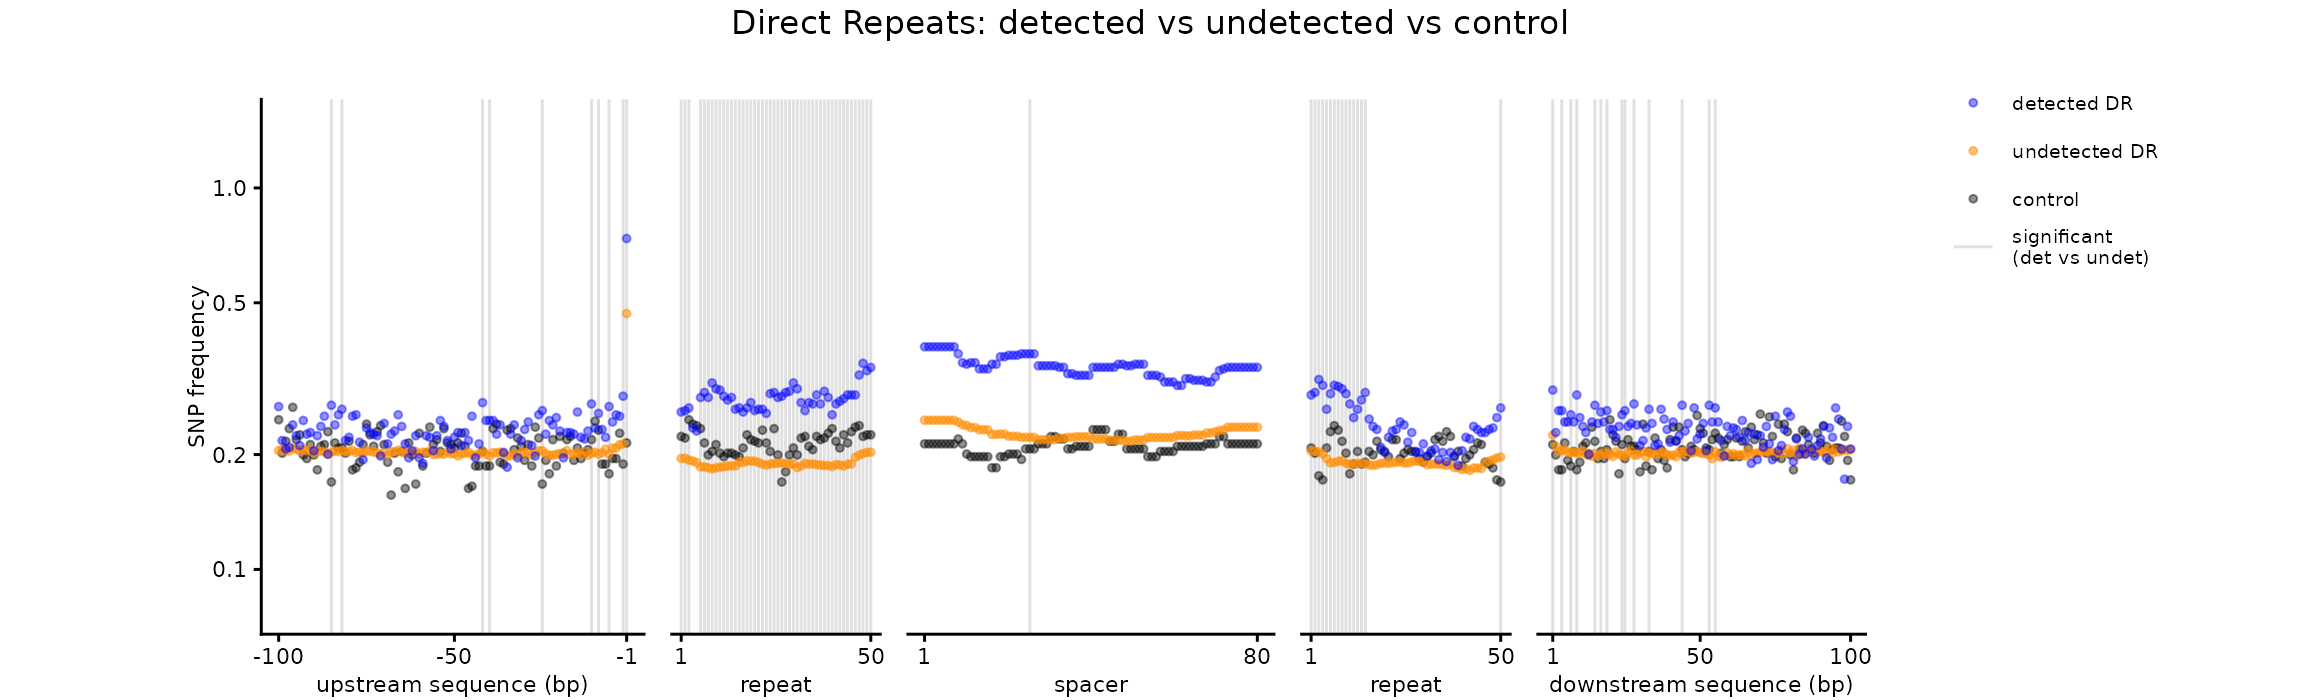

In [2]:
# R + ggplot 5-panel plot, detected / undetected / control
# Re-builds detected / control / undetected matrices and per-bin
# freqs from the .intersect files, writes freq CSVs, then plots via R + ggplot.
# Significance shading = IWTomics(detected vs undetected) from the .RData files
# produced by iwtomics_dr/run_iwtomics_dr_dvu.R.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/dr_notebook_detected_run"
os.chdir(WORKDIR)

MAX_FLANK    = 100
REPEAT_BINS  = 50
SPACER_BINS  = 80
PART_LEN = {"LeftRepeat": REPEAT_BINS, "Spacer": SPACER_BINS, "RightRepeat": REPEAT_BINS}
scaledposRepeat = [round(i, 4) for i in np.arange(1, REPEAT_BINS * 2, 2.0) / (REPEAT_BINS * 2)]
scaledposSpacer = [round(i, 4) for i in np.arange(1, SPACER_BINS * 2, 2.0) / (SPACER_BINS * 2)]

_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_DET, N_DET_SPACER = _counts["N_MOTIF"], _counts["N_MOTIF_SPACER"]
N_CTRL, N_CTRL_SPACER = _counts["N_CTRL"], _counts["N_CTRL_SPACER"]
if "N_UNDET" not in _counts or "N_UNDET_SPACER" not in _counts:
    raise RuntimeError(
        "N_UNDET / N_UNDET_SPACER not found in split_counts.txt -- run "
        "iwtomics_dr/run_iwtomics_dr_dvu.R first; it appends them.")
N_UNDET, N_UNDET_SPACER = _counts["N_UNDET"], _counts["N_UNDET_SPACER"]
print(f"N_DET={N_DET}({N_DET_SPACER} spacer)  "
      f"N_UNDET={N_UNDET}({N_UNDET_SPACER} spacer)  "
      f"N_CTRL={N_CTRL}({N_CTRL_SPACER} spacer)")

def _build_matrices_iwt(intersect_path, n_loci):
    out = {
        "left":        np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "right":       np.zeros((n_loci, MAX_FLANK),   dtype=np.float32),
        "LeftRepeat":  np.zeros((n_loci, REPEAT_BINS), dtype=np.float32),
        "Spacer":      np.zeros((n_loci, SPACER_BINS), dtype=np.float32),
        "RightRepeat": np.zeros((n_loci, REPEAT_BINS), dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype in PART_LEN and plen > 0:
                grid = scaledposRepeat if ptype.endswith("Repeat") else scaledposSpacer
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(grid):
                    if sp >= fs and sp < fe:
                        out[ptype][lid, i] += 1
    return out

print("building matrices (detected) ...")
det = _build_matrices_iwt("NCNR.DirectRepeats.gnomAD.intersect",          N_DET)
print("building matrices (control) ...")
ctl = _build_matrices_iwt("NCNR.DirectRepeats.gnomAD.shuffled.intersect", N_CTRL)
print("building matrices (undetected) ...")
und = _build_matrices_iwt("NCNR.DirectRepeats.gnomAD.undet.intersect",    N_UNDET)

def _freq(m, n): return m.sum(0) / n

pd.DataFrame({
    "LeftFlank":       _freq(det["left"],  N_DET),
    "ctrl_LeftFlank":  _freq(ctl["left"],  N_CTRL),
    "undet_LeftFlank": _freq(und["left"],  N_UNDET),
}).to_csv("iwt_dr_freq_dvu_LeftFlank.csv",  index=False)

pd.DataFrame({
    "RightFlank":       _freq(det["right"], N_DET),
    "ctrl_RightFlank":  _freq(ctl["right"], N_CTRL),
    "undet_RightFlank": _freq(und["right"], N_UNDET),
}).to_csv("iwt_dr_freq_dvu_RightFlank.csv", index=False)

# Spacer divisor: per-data-source N_*_SPACER (matches detected pipeline divisor)
center_df = {
    "LeftRepeat":        _freq(det["LeftRepeat"],  N_DET),
    "ctrl_LeftRepeat":   _freq(ctl["LeftRepeat"],  N_CTRL),
    "undet_LeftRepeat":  _freq(und["LeftRepeat"],  N_UNDET),
    "Spacer":            _freq(det["Spacer"],      N_DET_SPACER),
    "ctrl_Spacer":       _freq(ctl["Spacer"],      N_CTRL_SPACER),
    "undet_Spacer":      _freq(und["Spacer"],      N_UNDET_SPACER),
    "RightRepeat":       _freq(det["RightRepeat"], N_DET),
    "ctrl_RightRepeat":  _freq(ctl["RightRepeat"], N_CTRL),
    "undet_RightRepeat": _freq(und["RightRepeat"], N_UNDET),
}
maxL = max(PART_LEN.values())
center_padded = {k: np.concatenate([v, np.full(maxL - len(v), np.nan)]) for k, v in center_df.items()}
pd.DataFrame(center_padded).to_csv("iwt_dr_freq_dvu_center.csv", index=False)
print("wrote iwt_dr_freq_dvu_{LeftFlank,RightFlank,center}.csv")

R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/dr_notebook_detected_run")

load("DirectRepeats_detected_vs_undetected_IWTomics_left_0.01.RData")
load("DirectRepeats_detected_vs_undetected_IWTomics_right_0.01.RData")
load("DirectRepeats_detected_vs_undetected_IWTomics_center_0.01.RData")

freqL <- read.csv("iwt_dr_freq_dvu_LeftFlank.csv")
freqR <- read.csv("iwt_dr_freq_dvu_RightFlank.csv")
freqC <- read.csv("iwt_dr_freq_dvu_center.csv")

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Det    = freqL$LeftFlank,
                           Und    = freqL$undet_LeftFlank,
                           Ctrl   = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)
RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Det    = freqR$RightFlank,
                           Und    = freqR$undet_RightFlank,
                           Ctrl   = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

mk_part <- function(name, n_bins) {
  sig_rows <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart == name, ]
  data.frame(Levels = seq_len(n_bins),
             Det    = freqC[[name]][1:n_bins],
             Und    = freqC[[paste0("undet_", name)]][1:n_bins],
             Ctrl   = freqC[[paste0("ctrl_",  name)]][1:n_bins],
             Signif = sig_rows$significant)
}
LRDf <- mk_part("LeftRepeat",  50)
SPDf <- mk_part("Spacer",      80)
RRDf <- mk_part("RightRepeat", 50)

allv <- c(LeftFlankDf$Det, LeftFlankDf$Und, LeftFlankDf$Ctrl,
          RightFlankDf$Det, RightFlankDf$Und, RightFlankDf$Ctrl,
          LRDf$Det, LRDf$Und, LRDf$Ctrl,
          SPDf$Det, SPDf$Und, SPDf$Ctrl,
          RRDf$Det, RRDf$Und, RRDf$Ctrl)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c(
  "detected DR"             = rgb(t(col2rgb("blue")),       alpha = 110, maxColorValue = 255),
  "undetected DR"           = rgb(t(col2rgb("darkorange")), alpha = 130, maxColorValue = 255),
  "control"                 = rgb(t(col2rgb("black")),      alpha = 110, maxColorValue = 255),
  "significant\n(det vs undet)" = "grey88"
)

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),       size = 1) +
  geom_point(aes(y = Und,  col = "undetected DR"), size = 1) +
  geom_point(aes(y = Det,  col = "detected DR"),   size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

base_panel <- function(df, xlab, n_bins) {
  ggplot(df, aes(x = Levels)) +
    geom_vline(xintercept = df$Levels[df$Signif], col = "gray88") +
    geom_point(aes(y = Ctrl, col = "control"),       size = 1) +
    geom_point(aes(y = Und,  col = "undetected DR"), size = 1) +
    geom_point(aes(y = Det,  col = "detected DR"),   size = 1) +
    theme_classic() +
    theme(legend.position = "none",
          axis.text.x  = element_text(size = 8, family = "sans"),
          axis.title.x = element_text(size = 8, family = "sans"),
          axis.title.y = element_blank(),
          axis.text.y  = element_blank(),
          axis.ticks.y = element_blank(),
          axis.line.y  = element_blank()) +
    labs(x = xlab) +
    scale_colour_manual(name = "", values = cols) +
    scale_x_continuous(breaks = c(1, n_bins), limits = c(1, n_bins)) +
    theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
    scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)
}
p2 <- base_panel(LRDf, "repeat", 50)
p3 <- base_panel(SPDf, "spacer", 80)
p4 <- base_panel(RRDf, "repeat", 50)

p5 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\n(det vs undet)")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),       size = 1) +
  geom_point(aes(y = Und,  col = "undetected DR"), size = 1) +
  geom_point(aes(y = Det,  col = "detected DR"),   size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 7, family = "sans"),
        legend.position   = c(1.55, 0.90),
        legend.background = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("detected DR", "undetected DR", "control",
                                 "significant\n(det vs undet)")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 4))

g <- arrangeGrob(p1, p2, p3, p4, p5, ncol = 5,
                 widths = unit(c(60, 30, 50, 30, 75),
                               c("mm","mm","mm","mm","mm")),
                 top = textGrob("Direct Repeats: detected vs undetected vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("dr_snp_frequency_notebook_dvu_iwtomics.pdf", g, width = 11.5, height = 3.5, dpi = 300, bg='white')
ggsave("dr_snp_frequency_notebook_dvu_iwtomics.png", g, width = 11.5, height = 3.5, dpi = 200, bg='white')
cat("saved dr_snp_frequency_notebook_dvu_iwtomics.{pdf,png}\n")
"""

Path("plot_dr_dvu_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_dr_dvu_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("dr_snp_frequency_notebook_dvu_iwtomics.png"))
